# 交叉验证
在机器学习的实践中，我们常常面临一个核心问题：如何评估一个模型的好坏？你可能会想到，用一部分数据训练模型，然后用另一部分没见过的数据来测试它的表现。这个思路完全正确，但具体怎么做才能更可靠、更稳定地评估模型呢？这就是 交叉验证 要解决的核心问题。

简单来说，交叉验证是一种通过反复划分数据集来评估模型泛化能力（即处理新数据的能力）的统计方法，它就像给模型安排了一场模拟考试，通过多套不同的模拟试卷（数据子集）来检验其真实水平，避免因一次考试的偶然性而误判。

本文将带你深入理解交叉验证的原理、常见方法及其在模型优化与工程化中的关键作用。

----

## 为什么需要交叉验证？
在深入技术细节前，我们先通过一个比喻来理解其必要性。

想象你是一名学生，要参加一场重要的数学考试，评估你水平的方法有两种：

- 方法 A（简单划分）：老师从题库里随机抽 10 道题给你做一次模拟考，就用这个分数预测你的最终考试成绩。
- 方法 B（交叉验证）：老师把题库分成 5 份。第一次，用第 2、3、4、5 份题训练你，用第1份测试；第二次，用第 1、3、4、5 份训练，用第 2 份测试……如此重复 5 次。最后，取 5 次测试成绩的平均值来评估你。

哪种方法更可靠？显然是方法 B，因为它多次测试了你的能力，减少了偶然因素的影响。交叉验证就是方法 B 的实现，它通过多次划分数据集来评估模型的稳定性和泛化能力。
- 方法 A的风险在于：如果抽到的 10 道题恰好都是你擅长的题型，你的模拟考分数会虚高，导致对真实水平过于乐观；反之，如果抽到的都是你的知识盲点，分数又会过低，导致过于悲观。评估结果波动大，不稳定。
- 方法 B通过多次、不同的训练/测试组合，让你经历了题库中各种题型的考验，得到的平均分数更能代表你的综合、稳定水平，预测最终考试结果也更准确。

在机器学习中:
- 题库 就是我们的 数据集。
- 学生 就是我们训练的 机器学习模型。
- 模拟考分数 就是模型的评估指标（如准确率、均方误差等）
- 最终考试成绩 就是模型在真实应用中的表现。

交叉验证通过多次划分数据集来评估模型的性能，减少了偶然因素的影响，使得评估结果更稳定、更可靠。这就是为什么我们需要交叉验证的原因。

----

## 交叉验证的常见方法
交叉验证有多种实现方式，下面我们介绍几种常见的方法：



### 1. 留出法（Hold-out）
留出法是最简单的交叉验证方法。它将数据集随机划分为两部分：一部分用于训练模型，另一部分用于测试模型。通常的划分比例是 70% 训练，30% 测试，或者 80% 训练，20% 测试。

In [18]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 构造可运行的数据
# 200 条样本，4 个特征，二分类
np.random.seed(42)
X = np.random.randn(200, 4)
y = (X[:, 0] + X[:, 1] * 0.7 - X[:, 2] * 0.4 > 0).astype(int)

# 1. 划分训练集和测试集（7:3）
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 2. 训练模型
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# 3. 测试集评估
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"模型准确率: {accuracy:.4f}")

模型准确率: 0.8833


#### 流程说明
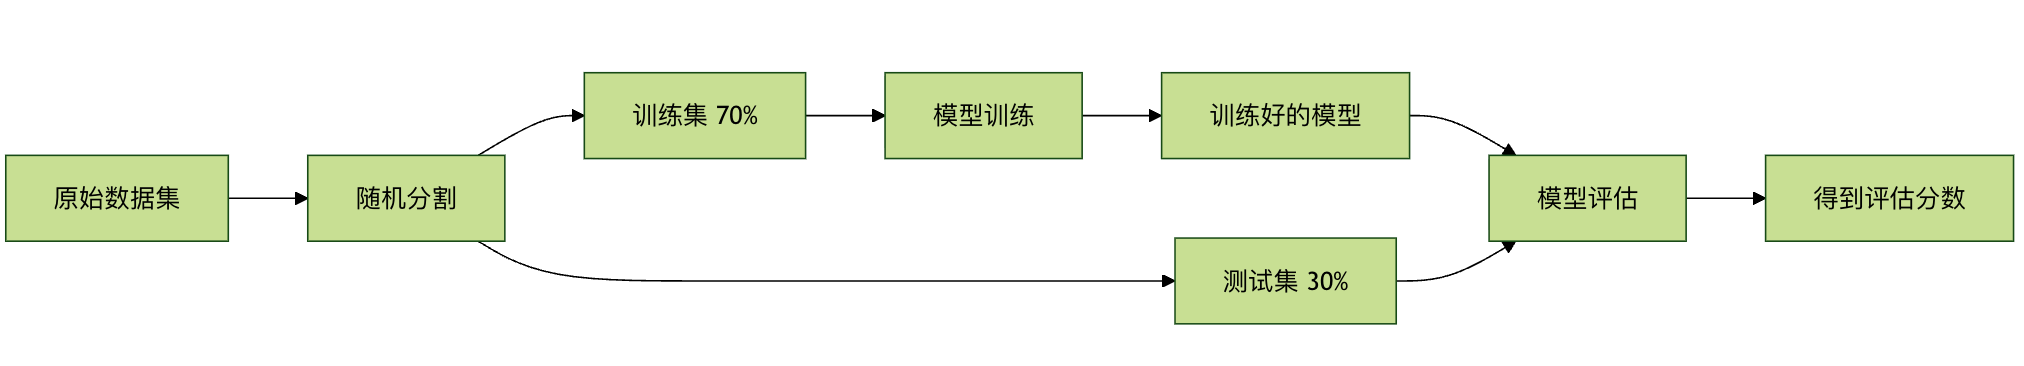

- 优点：
  - 简单易懂，计算效率高。
  - 适用于数据量较大的情况。
- 缺点：
  - 评估结果可能不稳定，受数据划分的偶然性影响较大。
  - 可能无法充分利用数据，尤其是当数据量较小时。

### 2. K 折交叉验证（K-fold Cross-validation）
K 折交叉验证是留出法的改进版本。它将数据集平均划分为 K 个子集（折），每次用 K-1 个子集训练模型，剩下的 1 个子集测试模型。这个过程重复 K 次，每次选择不同的子集作为测试集。最后，取 K 次测试结果的平均值作为模型的评估指标。

In [19]:
import numpy as np
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LogisticRegression

# 构造可运行的示例数据
# 100 条样本，4 个特征，二分类标签
np.random.seed(42)
X = np.random.randn(100, 4)
y = (X[:, 0] + X[:, 1] * 0.5 > 0).astype(int)

# 1. 初始化模型
model = LogisticRegression(max_iter=1000)

# 2. 定义 K 折交叉验证拆分器（K=5）
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# 3. 执行交叉验证
scores = cross_val_score(model, X, y, cv=kfold, scoring='accuracy')

print(f"每次折叠的准确率: {scores}")
print(f"平均准确率: {scores.mean():.4f} (+/- {scores.std() * 2:.4f})")

每次折叠的准确率: [0.9  0.95 1.   0.95 1.  ]
平均准确率: 0.9600 (+/- 0.0748)


#### k = 5 时的流程示意图
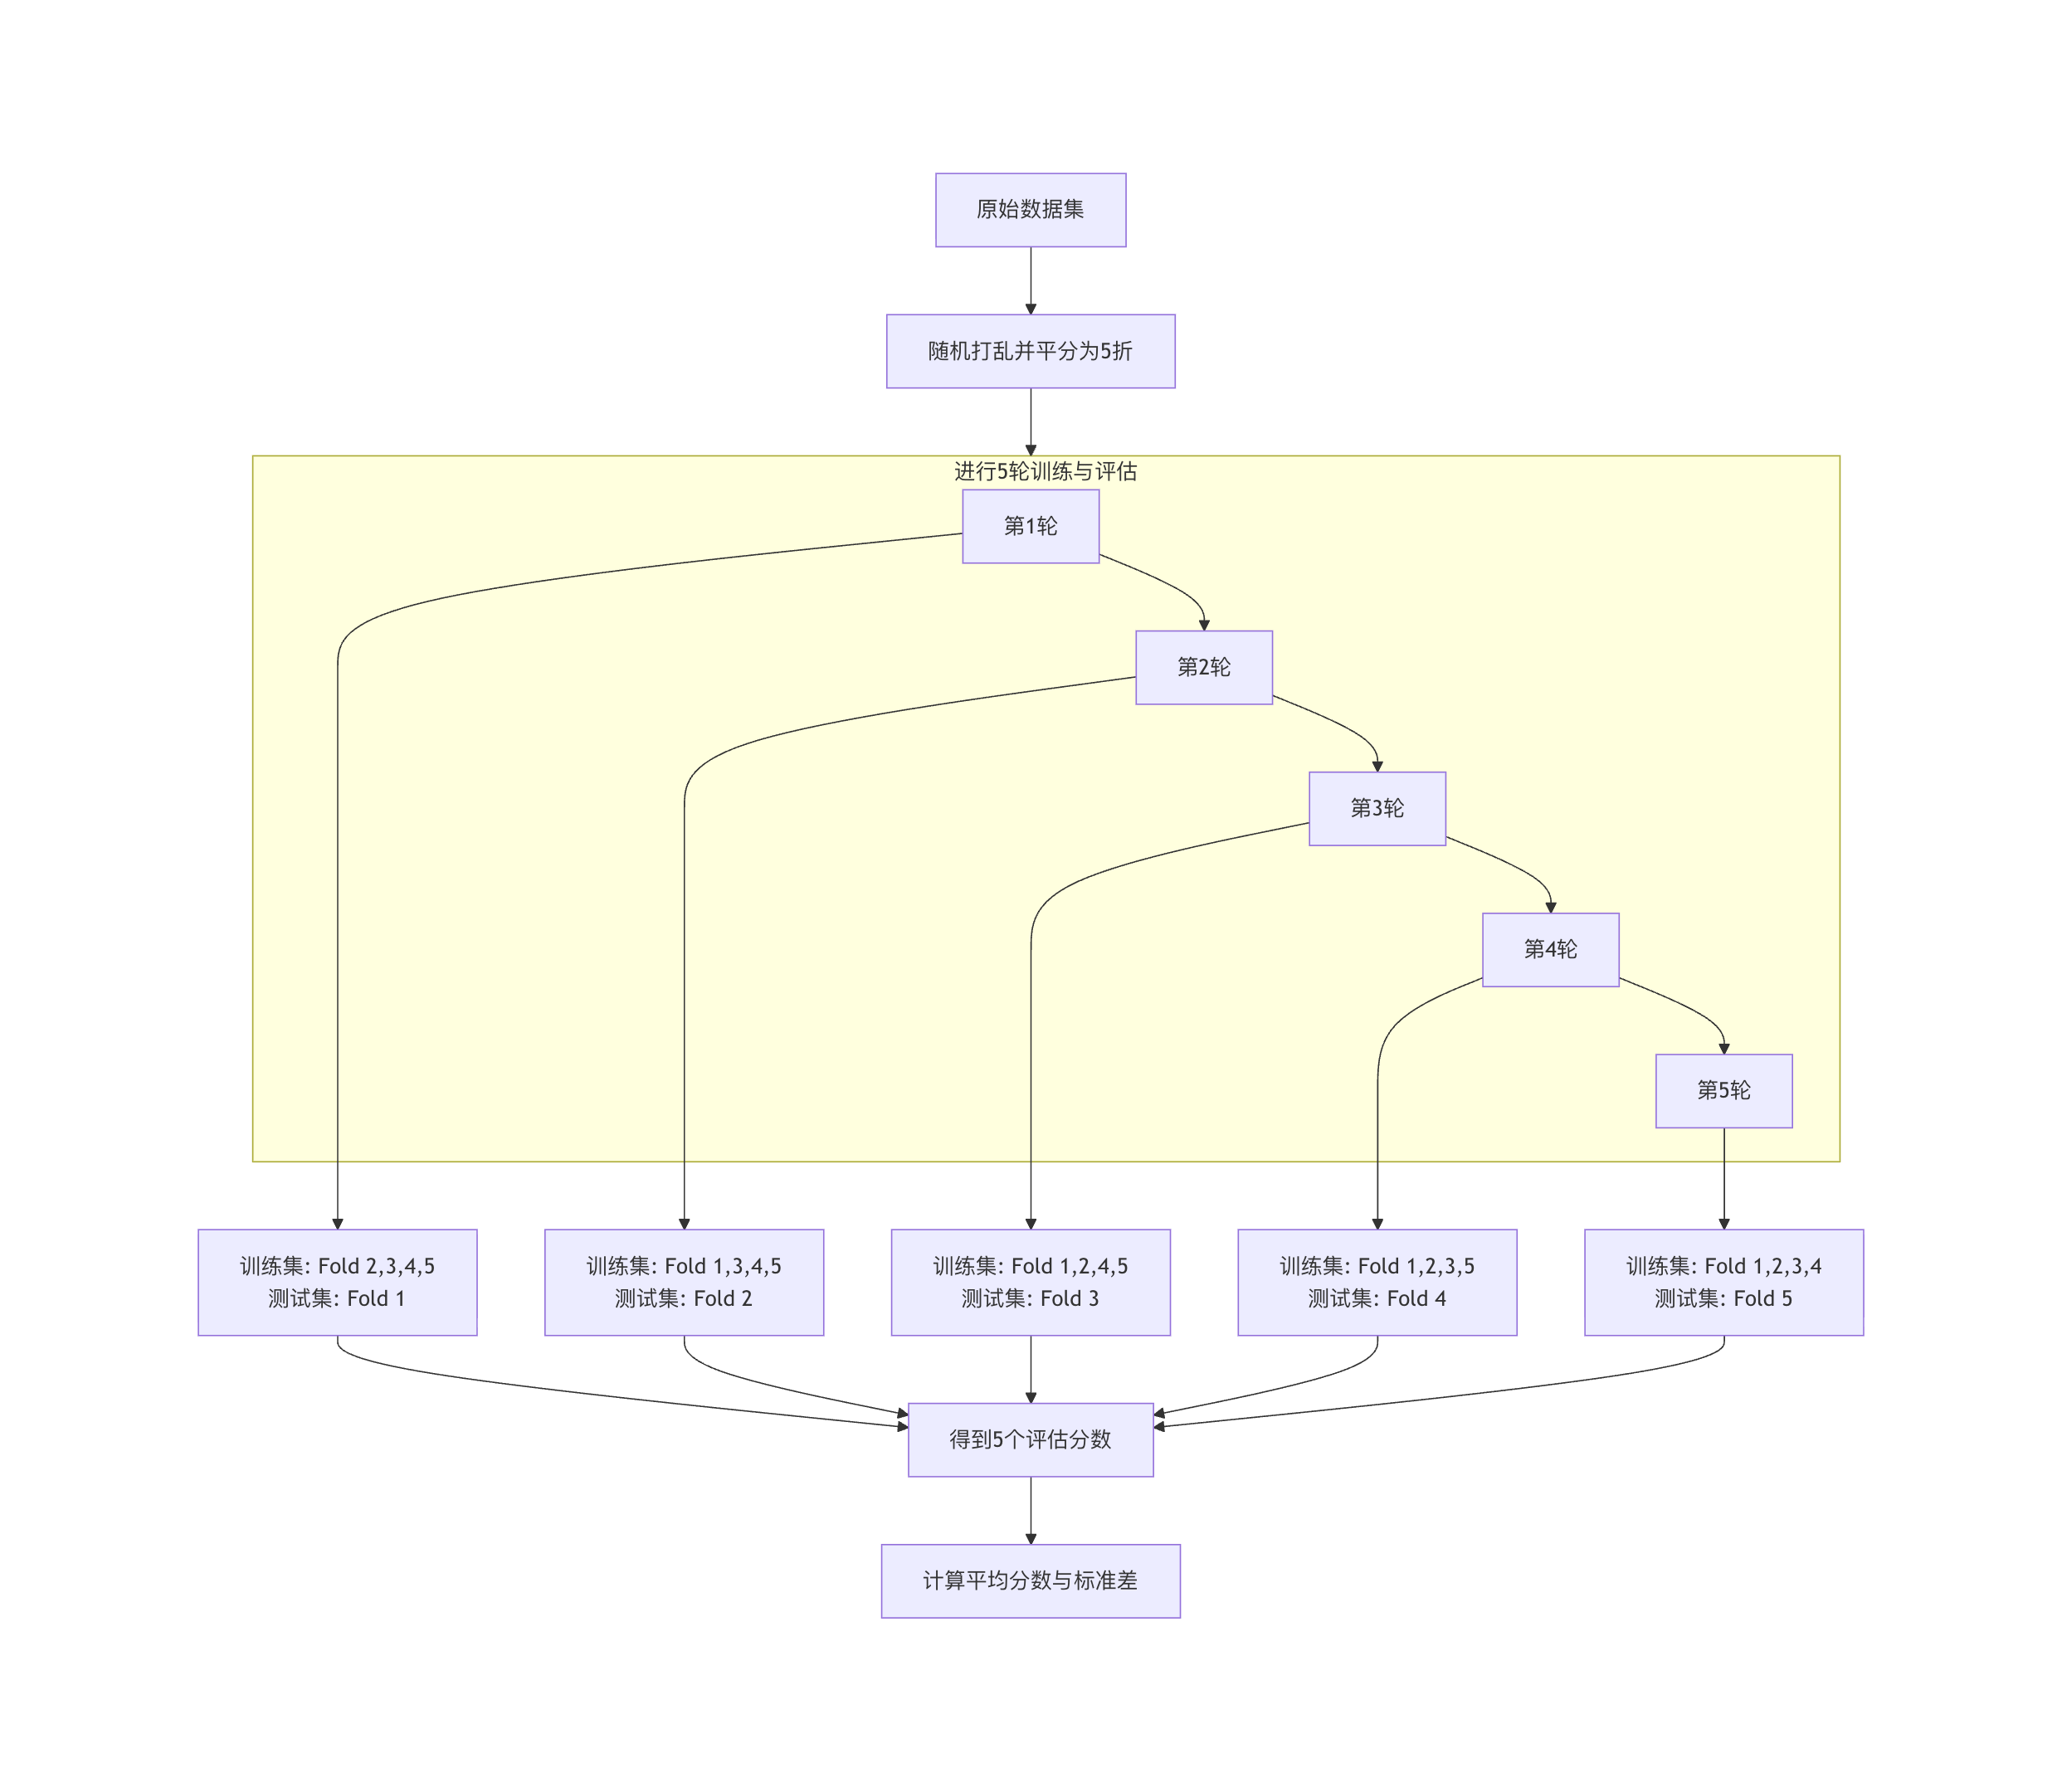

#### 如何选择 K 的值？
- 常用值 : 5 或 10 , 经验表明这两个值在大多数情况下都能提供稳定的评估结果。
- K 值较小(如3) : 训练集更大，但评估次数少，估计的方差可能较大。
- K 值较大(如20) : 评估次数多，估计的方差较小，但训练集较小，可能导致偏差增加。且计算成本较高。
- 极端情况 : K 等于数据集大小时，称为留一交叉验证（Leave-One-Out Cross-validation），每次只留一个样本作为测试集，其他样本作为训练集。这种方法评估结果最稳定，但计算成本极高。

- 优点：
  - 评估结果更稳定，减少了偶然因素的影响。
  - 更充分地利用了数据，尤其适合数据量较小的情况。
- 缺点：
  - 计算成本较高，尤其是 K 值较大时。是留出法的 K 倍。

### 3. 分层 K 折交叉验证（Stratified K-fold Cross-validation）
这是 K 折交叉验证的一个重要变体，特别适用于分类问题中类别分布不平衡的数据集。

解决的问题： 在普通的 K 折交叉验证中，随机分割可能导致某些折中某个类别的样本比例与原始数据集相差很大。例如，一个数据集中有 90% 的正类和 10% 的负类，随机分 5 折，有可能某一折里全是正类，没有负类，这会导致在该折上的评估失去意义。

分层 K 折交叉验证在分割时，会确保每一折中各个类别的样本比例与原始数据集中的总体比例保持一致。

In [20]:
from sklearn.model_selection import StratifiedKFold , cross_val_score           # StratifiedKFold 是分层 K 折交叉验证的拆分器 , cross_val_score 用于执行交叉验证并计算评估指标

stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X, y, cv=stratified_kfold, scoring='accuracy')

对于分类任务 , 尤其是类别分布不平衡的情况 , 使用分层 K 折交叉验证可以获得更可靠的评估结果。

### 4. 时间序列交叉验证（Time Series Cross-validation）
对于时间序列数据，数据的顺序至关重要（明天的数据依赖于今天和昨天的）。我们不能随机打乱数据，必须保持时间顺序。

其原理是：训练集总是由时间上较早的数据构成，测试集是紧随其后的数据。随着折数增加，训练集窗口不断扩大。

In [21]:
import numpy as np
from sklearn.model_selection import TimeSeriesSplit

# 构造可运行的时间序列数据
# 100 个时间点，2 个特征
np.random.seed(42)
X = np.random.randn(100, 2)

# TimeSeriesSplit 示例
tscv = TimeSeriesSplit(n_splits=5)

for train_index, test_index in tscv.split(X):
    print(f"训练集索引范围: {train_index[0]} 到 {train_index[-1]}")
    print(f"测试集索引范围: {test_index[0]} 到 {test_index[-1]}")
    print("---")

训练集索引范围: 0 到 19
测试集索引范围: 20 到 35
---
训练集索引范围: 0 到 35
测试集索引范围: 36 到 51
---
训练集索引范围: 0 到 51
测试集索引范围: 52 到 67
---
训练集索引范围: 0 到 67
测试集索引范围: 68 到 83
---
训练集索引范围: 0 到 83
测试集索引范围: 84 到 99
---


------

## 交叉验证在模型工程化中的应用
交叉验证不仅是评估模型性能的工具，也是模型优化和工程化过程中不可或缺的一环。通过合理使用交叉验证，我们可以更有效地进行模型选择、超参数调优以及最终模型的部署。


### 应用一 : 模型选择与比较
当需要在多个候选模型（如线性回归、决策树、支持向量机）中选择一个时，我们不能用测试集来选（否则测试集就变成了训练过程的一部分，会"泄漏"信息）。正确的做法是：使用交叉验证来评估每个模型的性能，然后选择在交叉验证中表现最好的模型。

- 1. 对每个候选模型，使用相同的交叉验证方法（如 5 折交叉验证）评估其性能指标（如准确率、均方误差等）。
- 2. 比较各模型的平均评估指标，选择表现最好的模型。
- 3. 最后，在选定的模型上使用独立的测试集进行最终评估，以获得对模型在真实应用中表现的可靠估计。

In [22]:
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# 构造可运行的分类数据
# 200 个样本 , 4 个特征 , 二分类
np.random.seed(42)
X = np.random.randn(200 , 4)
y = (X[: , 0] + X[: , 1] * 0.8 - X[: , 2] * 0.3 > 0).astype(int)            # astypeh 将布尔值转换为整数标签 (0 和 1)

# 划分训练集 / 测试集
X_train , X_test , y_train , y_test = train_test_split(
    X , y , test_size=0.25 , random_state=42 , stratify=y
    )

# 定义模型
models = {
    "Logistic Regression" : LogisticRegression(max_iter=1000) ,         # max_iter 是最大迭代次数参数
    "SVM" : SVC(random_state=42) ,
    "Decision Tree" : DecisionTreeClassifier(random_state=42)
}

# 使用分层 K 折交叉验证评估每个模型
cv = StratifiedKFold(n_splits=5 , shuffle=True , random_state=42)
results = {}

for name , model in models.items():
    scores = cross_val_score(model , X_train , y_train , cv=cv , scoring='accuracy')
    results[name] = scores
    print(f"{name} - 每折准确率: {scores} - 平均准确率: {scores.mean():.4f} (+/- {scores.std() * 2:.4f})")

# 选择表现最好的模型
best_model_name = max(results , key=lambda k: results[k].mean())
best_model = models[best_model_name]
print(f"\n表现最好的模型: {best_model_name}")

# 最终训练与测试
best_model.fit(X_train , y_train)
y_pred = best_model.predict(X_test)
final_accuracy = accuracy_score(y_test , y_pred)
print(f"{best_model_name} 在测试集上的准确率: {final_accuracy:.4f}")

Logistic Regression - 每折准确率: [0.93333333 0.93333333 0.96666667 0.96666667 0.96666667] - 平均准确率: 0.9533 (+/- 0.0327)
SVM - 每折准确率: [0.93333333 0.9        0.93333333 1.         0.93333333] - 平均准确率: 0.9400 (+/- 0.0653)
Decision Tree - 每折准确率: [0.86666667 0.9        0.9        0.86666667 0.66666667] - 平均准确率: 0.8400 (+/- 0.1759)

表现最好的模型: Logistic Regression
Logistic Regression 在测试集上的准确率: 1.0000


### 应用二 : 超参数调优
超参数是模型训练前需要设定的参数（如随机森林的树数量 n_estimators、SVM 的惩罚系数 C）。寻找最佳超参数组合的过程称为超参数调优，交叉验证是其标准评估方法。

最常用的方法是网格搜索交叉验证

In [23]:
import numpy as np
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestClassifier

# 构造可运行的分类数据
# 300 条样本，5 个特征，二分类
np.random.seed(42)
X = np.random.randn(300, 5)
y = (X[:, 0] * 0.6 + X[:, 1] * 0.4 - X[:, 2] > 0).astype(int)

# 划分训练集 / 测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# 1. 参数网格
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

# 2. 基础模型
rf = RandomForestClassifier(random_state=42)

# 3. GridSearchCV
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# 4. 网格搜索（仅训练集）
grid_search.fit(X_train, y_train)

# 5. 最优参数与分数
print(f"最佳参数: {grid_search.best_params_}")
print(f"最佳交叉验证分数: {grid_search.best_score_:.4f}")

# 6. 测试集评估
best_rf_model = grid_search.best_estimator_
test_accuracy = best_rf_model.score(X_test, y_test)
print(f"调优后模型在测试集上的准确率: {test_accuracy:.4f}")

最佳参数: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
最佳交叉验证分数: 0.9067
调优后模型在测试集上的准确率: 0.9467
